# 02 - High-dimensional ML baselines for proteomics

This notebook demonstrates a leakage-safe baseline modelling workflow for high-dimensional proteomics data.

The goal is not to claim clinical validity. The goal is to show that we understand the modelling risks common in proteomics:

- small sample size
- many proteins/features
- missingness and below-LOD effects
- feature selection leakage
- overfitting risk
- need for calibration, reproducibility, and validation discipline

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from proteomics_index.modeling import make_baseline_models, evaluate_cv_models, top_selected_features
from proteomics_index.synthetic_data import SyntheticOlinkConfig, generate_synthetic_olink_npx
from proteomics_index.qc import filter_npx, long_to_wide

DATA_PROCESSED = ROOT / "data" / "processed"
REPORTS = ROOT / "reports"
REPORTS.mkdir(parents=True, exist_ok=True)

## 1. Load processed ML-ready proteomics matrix

If Notebook 01 has not been run, this cell creates the processed files from the included synthetic NPX dataset.

In [2]:
X_path = DATA_PROCESSED / "X_proteomics.csv"
y_path = DATA_PROCESSED / "y_severe_outcome.csv"
meta_path = DATA_PROCESSED / "metadata_model.csv"

if not X_path.exists() or not y_path.exists() or not meta_path.exists():
    npx, metadata = generate_synthetic_olink_npx(
        SyntheticOlinkConfig(n_samples=96, n_proteins=240, signal_proteins=20, random_state=42)
    )
    filtered_npx = filter_npx(npx, max_sample_missing=0.35, max_protein_missing=0.40)
    X_wide = long_to_wide(filtered_npx, feature_col="Assay")
    model_table = metadata.merge(X_wide, on="SampleID", how="inner")
    protein_features = [c for c in X_wide.columns if c != "SampleID"]
    X_tmp = model_table[protein_features]
    y_tmp = model_table["SevereOutcome"].astype(int)
    meta_tmp = model_table[["SampleID", "Age", "Sex", "BMI", "WHO_Severity", "SevereOutcome", "PlateID", "SampleQC"]]
    X_tmp.assign(SampleID=meta_tmp["SampleID"].values).to_csv(X_path, index=False)
    y_tmp.to_frame("SevereOutcome").assign(SampleID=meta_tmp["SampleID"].values).to_csv(y_path, index=False)
    meta_tmp.to_csv(meta_path, index=False)

X_with_id = pd.read_csv(X_path)
y_with_id = pd.read_csv(y_path)
metadata = pd.read_csv(meta_path)

sample_ids = X_with_id["SampleID"]
X = X_with_id.drop(columns=["SampleID"])
y = y_with_id["SevereOutcome"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("p > n:", X.shape[1] > X.shape[0])
display(metadata.head())

X shape: (96, 240)
y shape: (96,)
p > n: True


,SampleID,SubjectID,Age,Sex,BMI,DiseaseStatus,WHO_Severity,SevereOutcome,CollectionDay,PlateID,SampleQC
0,S001,P001,29,Male,17.0,Control,1,0,22,Plate_C,Pass
1,S002,P002,68,Female,28.3,Case,4,0,20,Plate_C,Pass
2,S003,P003,61,Female,22.9,Control,3,0,1,Plate_C,Warning
3,S004,P004,49,Female,24.9,Control,4,0,5,Plate_C,Pass
4,S005,P005,49,Male,23.9,Control,3,0,0,Plate_C,Pass


## 2. Class balance and high-dimensional risk

A core clinical proteomics risk is apparent performance inflation from data leakage or excessive feature search. We therefore keep all imputation, scaling, and feature selection inside the cross-validation pipeline.

In [3]:
class_balance = y.value_counts(normalize=True).rename("proportion").to_frame()
class_balance["count"] = y.value_counts()
display(class_balance)

print(f"Samples: {X.shape[0]}")
print(f"Proteins/features: {X.shape[1]}")
print(f"Feature-to-sample ratio: {X.shape[1] / X.shape[0]:.2f}")

,proportion,count
SevereOutcome,,
0,0.833333,80
1,0.166667,16


Samples: 96
Proteins/features: 240
Feature-to-sample ratio: 2.50


## 3. Leakage-safe baseline models

Models:

- **Dummy**: no-signal benchmark
- **Elastic Net Logistic Regression**: sparse, interpretable baseline suitable for high-dimensional data
- **Random Forest**: nonlinear baseline, controlled to reduce overfitting

Feature selection happens **inside** each CV fold.

In [4]:
k_features = min(40, X.shape[1])
models = make_baseline_models(k_features=k_features, random_state=42)

results = evaluate_cv_models(X, y, models, n_splits=5, random_state=42)
display(results.round(3))

results.to_csv(REPORTS / "baseline_model_results.csv")

/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to

,AUROC,AUPRC,Brier,Sensitivity,Specificity
Model,,,,,
ElasticNet_LogReg,0.970,0.909,0.051,0.812,0.938
RandomForest,0.952,0.888,0.078,0.438,1.000
Dummy,0.475,0.160,0.139,0.000,1.000


## 4. Visual comparison

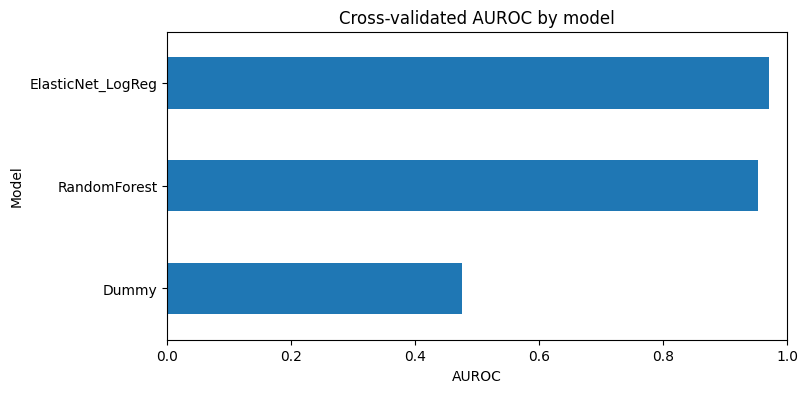

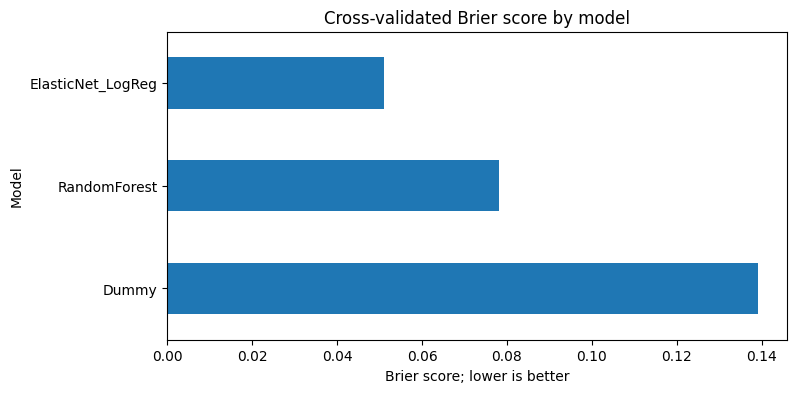

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
results["AUROC"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Cross-validated AUROC by model")
ax.set_xlabel("AUROC")
ax.set_xlim(0, 1)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
results["Brier"].sort_values(ascending=False).plot(kind="barh", ax=ax)
ax.set_title("Cross-validated Brier score by model")
ax.set_xlabel("Brier score; lower is better")
plt.show()

## 5. Candidate protein signature from the sparse baseline

This is not a validated biomarker panel. It is an example of how a clinical index team might start identifying candidate proteins for review, replication, calibration, and biological interpretation.

In [6]:
selected = top_selected_features(models["ElasticNet_LogReg"], X, y, top_n=20)
display(selected)

selected.to_csv(REPORTS / "candidate_protein_signature.csv", index=False)

/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,feature,anova_f_score
15,Protein_016,41.382863
11,Protein_012,36.256054
12,Protein_013,29.739841
10,Protein_011,27.152092
18,Protein_019,17.734980
1,Protein_002,17.185676
17,Protein_018,16.952817
16,Protein_017,16.777324
13,Protein_014,16.641622
9,Protein_010,15.181136


## 6. What this proves for a clinical AI portfolio

This notebook establishes the **high-dimensional ML baseline layer**:

- a clean sample-by-protein matrix
- explicit p > n awareness
- leakage-safe cross-validation
- baseline comparison against a dummy model
- sparse feature-selection logic
- clinical-style metrics including AUROC, AUPRC, Brier, sensitivity, and specificity

The next layer should add calibration curves, bootstrap confidence intervals, conformal prediction, index score conversion, and clinician-facing report generation.